# Task 2 — Ball Count Prediction
**Principle**: fix a baseline, then change one variable per run. Every difference is then attributable to a single cause.

Logic lives in `testing/task2/` and `models/cnn_pipeline.py`. This notebook only configures, runs, and displays.

In [2]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path

from testing.config import DEFAULT_CFG, TRAIN_DIR, VALID_DIR, TEST_DIR, EXPERIMENTS_DIR
from testing.utils import imread_rgb, show_many
from testing.task2 import (
    run_experiment,
    plot_history, plot_scatter,
    plot_error_by_count, plot_error_distribution,
    show_worst_predictions,
)
from models.cnn_pipeline import count_balls_from_label

---
## Data Exploration

In [3]:
def get_counts(split_dir):
    return [count_balls_from_label(split_dir / 'labels' / (p.stem + '.txt'))
            for p in sorted((split_dir / 'images').glob('*.jpg'))]

train_counts = get_counts(TRAIN_DIR)
valid_counts = get_counts(VALID_DIR)
test_counts  = get_counts(TEST_DIR)

print(f'Train: {len(train_counts)} images  |  Valid: {len(valid_counts)}  |  Test: {len(test_counts)}')
print(f'Train count range: {min(train_counts)}–{max(train_counts)}  mean={np.mean(train_counts):.1f}  median={np.median(train_counts):.0f}')

Train: 199 images  |  Valid: 24  |  Test: 24
Train count range: 2–16  mean=11.4  median=12


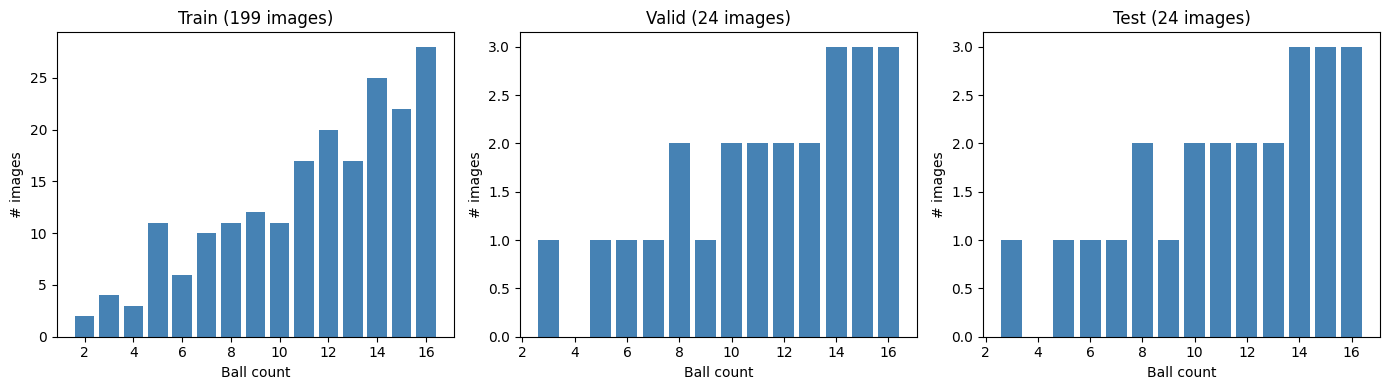

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, counts, label in zip(axes, [train_counts, valid_counts, test_counts], ['Train', 'Valid', 'Test']):
    c = Counter(counts)
    keys = sorted(c)
    ax.bar(keys, [c[k] for k in keys], color='steelblue')
    ax.set_title(f'{label} ({len(counts)} images)')
    ax.set_xlabel('Ball count')
    ax.set_ylabel('# images')
plt.tight_layout()
plt.show()

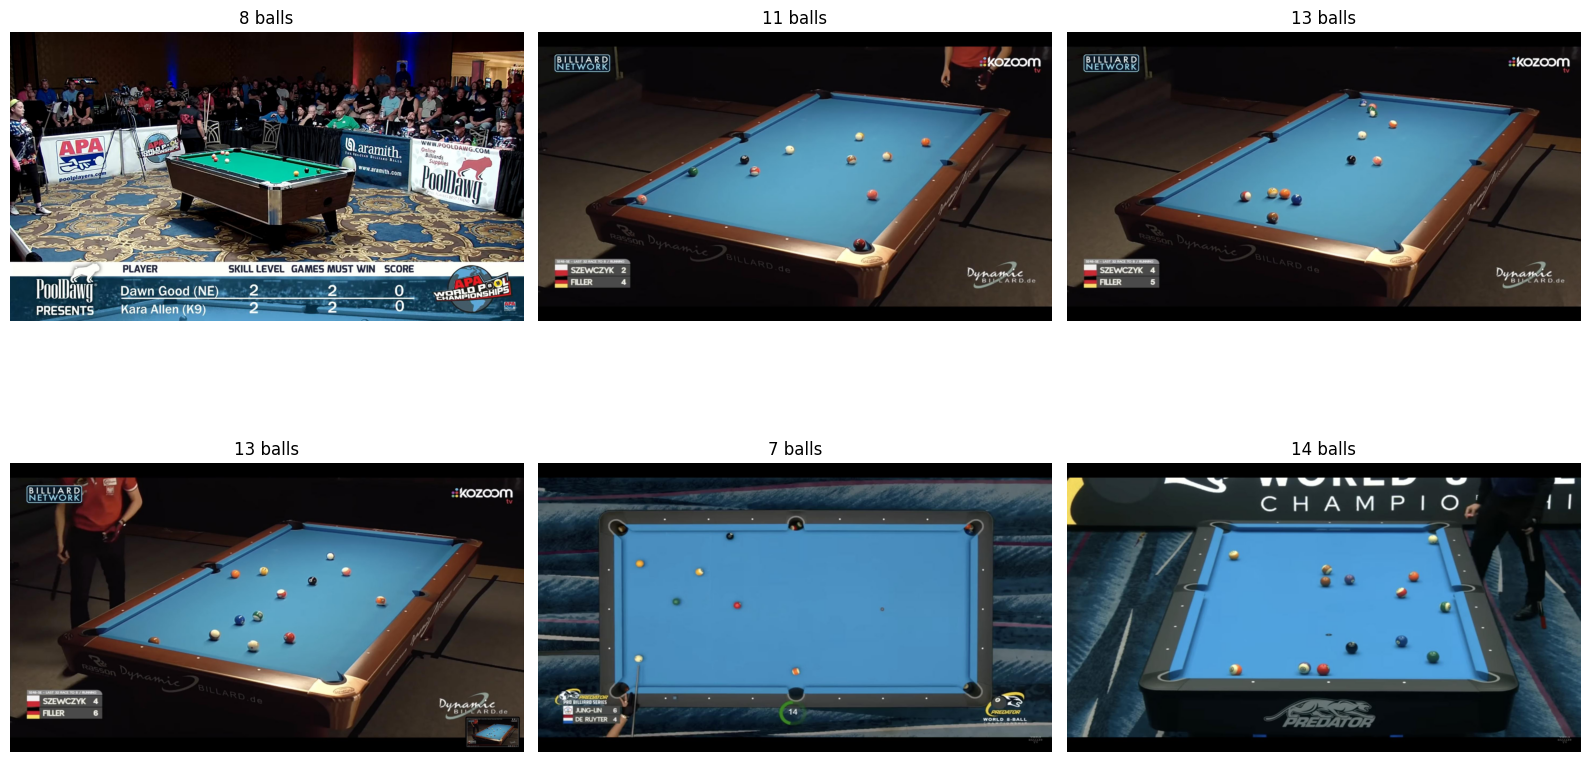

In [5]:
# Sample images from train
sample_paths  = sorted((TRAIN_DIR / 'images').glob('*.jpg'))[:6]
sample_imgs   = [imread_rgb(p) for p in sample_paths]
sample_titles = [f'{count_balls_from_label(TRAIN_DIR / "labels" / (p.stem + ".txt"))} balls' for p in sample_paths]
show_many(sample_imgs, titles=sample_titles, cols=3)

---
## Naive Baseline — Must Beat This
Before any training, compute the MAE of a constant predictor.
The optimal constant for MAE is the **median** (not the mean — the mean minimises MSE).
If the CNN doesn't beat this, it isn't learning anything.

In [6]:
train_median = int(np.median(train_counts))
train_mean   = np.mean(train_counts)

naive_mae_median = np.mean(np.abs(np.array(valid_counts) - train_median))
naive_mae_mean   = np.mean(np.abs(np.array(valid_counts) - train_mean))

print(f'Training median = {train_median}  →  valid MAE = {naive_mae_median:.3f}')
print(f'Training mean   = {train_mean:.1f}  →  valid MAE = {naive_mae_mean:.3f}')
print(f'\nFloor to beat: valid MAE < {naive_mae_median:.3f}')

Training median = 12  →  valid MAE = 3.042
Training mean   = 11.4  →  valid MAE = 3.091

Floor to beat: valid MAE < 3.042


---
# Run 1 — Baseline
## Design Rationale

### Data pipeline
- **384×384 square resize** — pool balls are small relative to the full frame. Downsampling to 224px merges clustered balls into indistinguishable blobs, which directly caps counting accuracy. Square resize (vs letterbox) is a Run-5 ablation; for the baseline, simplicity wins.
- **ImageNet normalisation** — pretrained ResNet was trained on ImageNet statistics; using the same mean/std ensures the pretrained features are in the right activation range from epoch 0.
- **Light augmentation: horizontal flip + brightness/contrast jitter** — horizontal flip is semantically free (a flipped table still has N balls). Photometric jitter matters because broadcast lighting varies widely and the undisclosed test images will likely differ from training. No vertical flip or rotation — these break the perspective prior and can push balls partially out of frame.

### Model
- **ResNet18, ImageNet-pretrained** — with only 199 training images, transfer learning is near-mandatory. Training from scratch would overfit. ResNet18 is small enough not to memorise the training set.
- **Head: `Dropout(0.2) → Linear(512, 1)`** — single scalar output (regression framing). Dropout adds cheap regularisation on top of a tiny dataset. Shallow head avoids piling on capacity that has no data to be justified.
- **Full fine-tune, low LR** — pool frames look very different from ImageNet, so the backbone genuinely needs to adapt. Freezing would underfit. The low LR (1e-4) protects pretrained features early in training.
- **Round and clamp to [0, 16]** at inference — domain knowledge: can't have negative or more than 16 balls. Applied only to the final reported integer, not the training loss.

### Training
- **Smooth L1 (Huber) loss** — aligns with the MAE objective without letting a few crowded-table images dominate the gradient (which MSE would allow). Smoother than pure L1 near zero, which stabilises gradients for near-correct predictions.
- **Adam, LR 1e-4** — safe default for fine-tuning; higher LR risks destroying pretrained weights.
- **ReduceLROnPlateau on valid MAE, patience=7** — small datasets converge fast and overfit fast. The scheduler reacts to the validation curve rather than decaying blindly.
- **40 epochs, checkpoint best valid MAE** — keeps the best snapshot rather than the last epoch.

In [7]:
BASELINE_CFG = {**DEFAULT_CFG,
    'name': 'resnet18_reg', 'backbone': 'resnet18', 'head': 'regression',
    'input_size': 384, 'augment': 'light', 'loss': 'smooth_l1',
    'optimizer': 'adam', 'lr': 1e-4, 'epochs': 40, 'batch_size': 16, 'seed': 42}

results_1, history_1 = run_experiment(BASELINE_CFG)


  Run : resnet18_reg
  resnet18 | head=regression | size=384 | aug=light | device=cpu
  Epoch   1/40  train_loss=10.3694  val_mae=11.0833
  Epoch   5/40  train_loss=5.4933  val_mae=5.1667
  Epoch  10/40  train_loss=2.5670  val_mae=2.3333
  Epoch  15/40  train_loss=1.1527  val_mae=1.7500
  Epoch  20/40  train_loss=0.5369  val_mae=1.0417
  Epoch  25/40  train_loss=0.6006  val_mae=1.3333
  Epoch  30/40  train_loss=0.5464  val_mae=1.2917
  Epoch  35/40  train_loss=0.4840  val_mae=1.2083
  Epoch  40/40  train_loss=0.4670  val_mae=1.1667
Best val_mae=0.9583  →  saved resnet18_reg.pth

  [Valid]  MAE=0.958  Acc=41.67%  Off1=70.83%
  [Test]   MAE=1.083  Acc=37.50%  Off1=75.00%


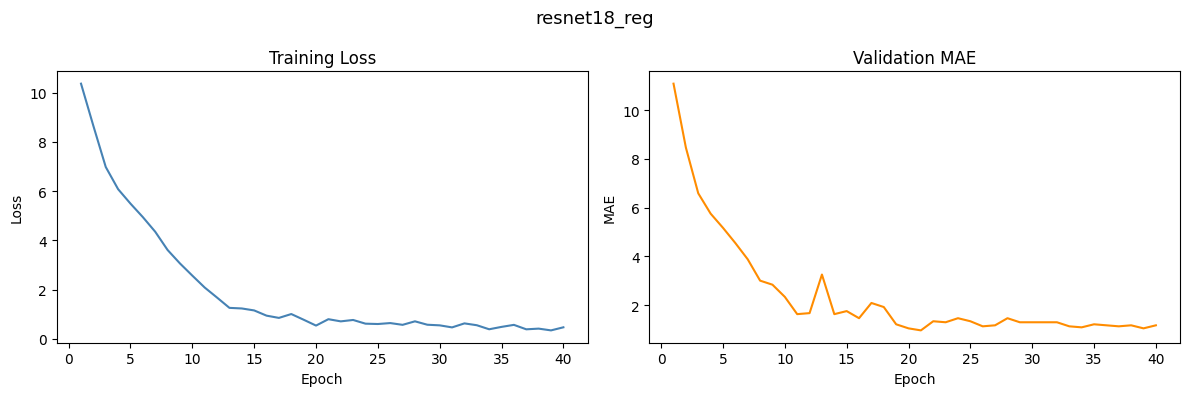

In [8]:
plot_history(history_1, cfg=BASELINE_CFG)

In [9]:
for split in ('valid', 'test'):
    m = results_1[split]
    print(f'[{split:5}]  MAE={m["mae"]:.3f}  Exact={m["acc"]:.2%}  Off-by-1={m["off1"]:.2%}')

[valid]  MAE=0.958  Exact=41.67%  Off-by-1=70.83%
[test ]  MAE=1.083  Exact=37.50%  Off-by-1=75.00%


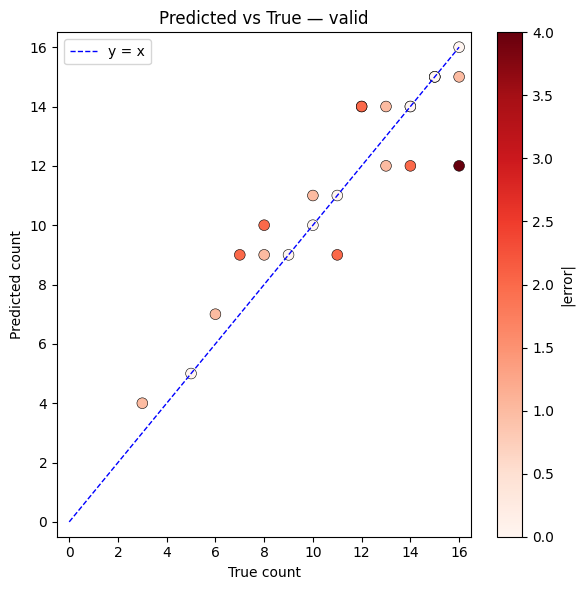

In [10]:
plot_scatter(results_1, split='valid')

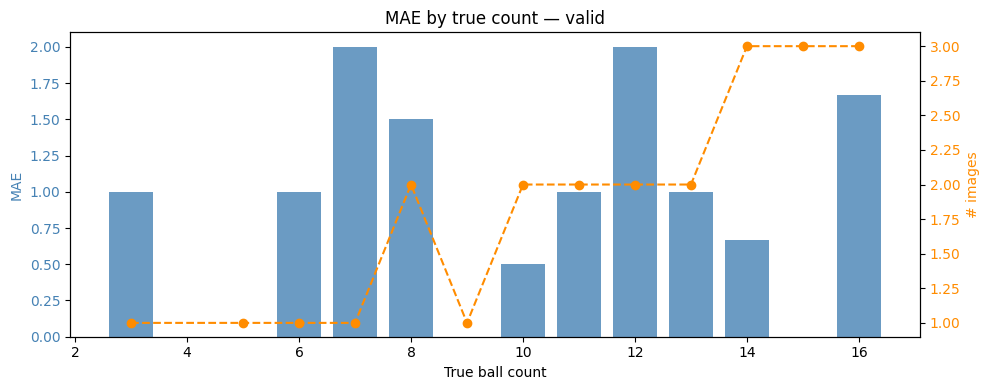

In [11]:
plot_error_by_count(results_1, split='valid')

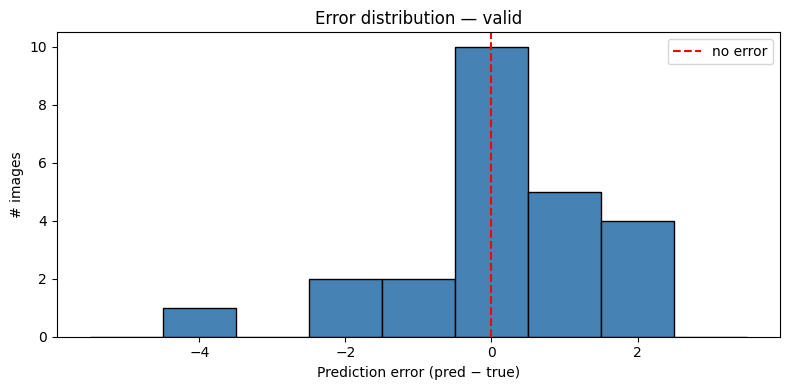

In [12]:
plot_error_distribution(results_1, split='valid')

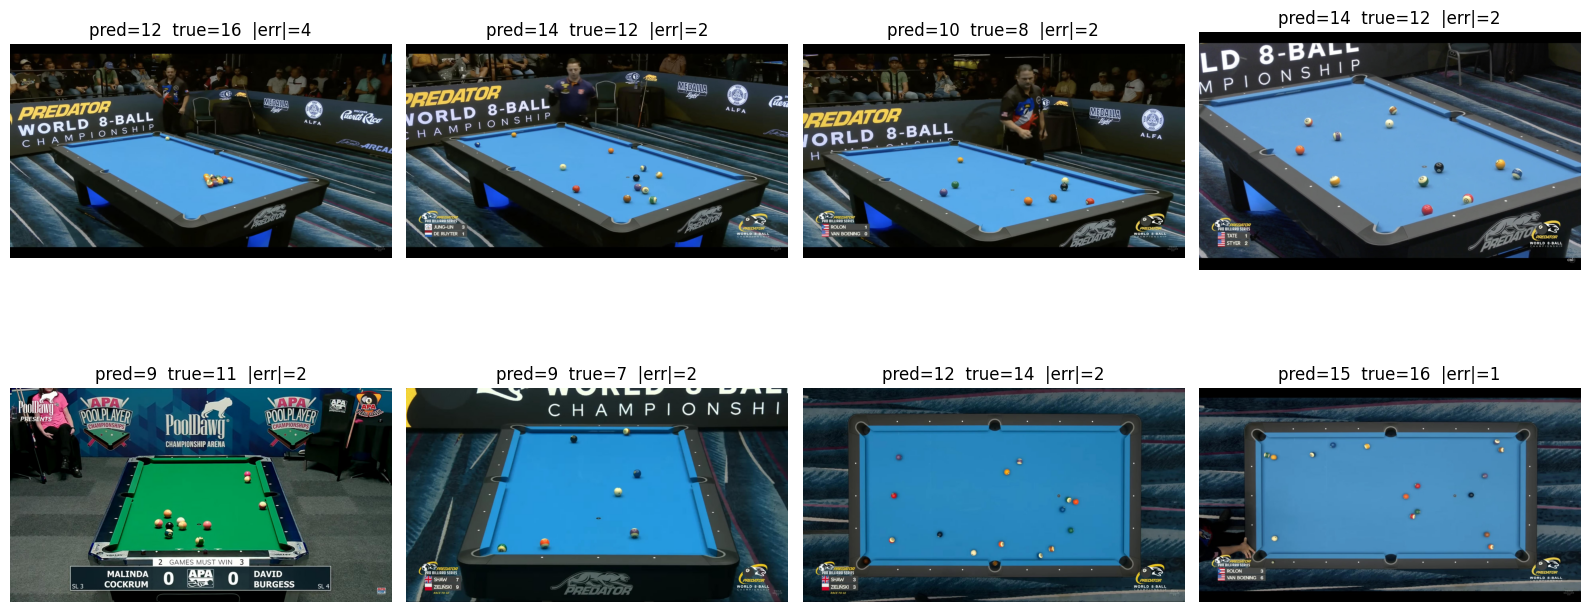

In [13]:
show_worst_predictions(results_1, split='valid', k=8)

---
# Run 2 — Scratch CNN (regularised)
**Variable isolated**: pretrained features vs training from scratch.

To make this a fair comparison, the scratch model is regularised (BatchNorm + Dropout 0.4 in the head) and uses a higher LR appropriate for random initialisation. Without regularisation, "from scratch is worse" proves nothing — it would just be "unregularised model fails on small data".

In [ ]:
cfg_2 = {**DEFAULT_CFG,
    'name': 'scratch_reg', 'backbone': 'scratch', 'head': 'regression',
    'input_size': 224, 'augment': 'light', 'loss': 'smooth_l1',
    'optimizer': 'adam', 'lr': 1e-3, 'epochs': 40, 'batch_size': 16, 'seed': 42}

results_2, history_2 = run_experiment(cfg_2)
plot_history(history_2, cfg=cfg_2)
for split in ('valid', 'test'):
    m = results_2[split]
    print(f'[{split:5}]  MAE={m["mae"]:.3f}  Exact={m["acc"]:.2%}  Off-by-1={m["off1"]:.2%}')

In [ ]:
plot_scatter(results_2)
plot_error_by_count(results_2)
plot_error_distribution(results_2)
show_worst_predictions(results_2, k=8)

---
# Run 3 — ResNet34 (more capacity)
**Variable isolated**: backbone depth/capacity, everything else identical to baseline.

With 199 images, ResNet34 may overfit more than ResNet18. If it does better, capacity is the bottleneck; if it does worse, small-data overfitting dominates.

In [ ]:
cfg_3 = {**BASELINE_CFG, 'name': 'resnet34_reg', 'backbone': 'resnet34'}

results_3, history_3 = run_experiment(cfg_3)
plot_history(history_3, cfg=cfg_3)
for split in ('valid', 'test'):
    m = results_3[split]
    print(f'[{split:5}]  MAE={m["mae"]:.3f}  Exact={m["acc"]:.2%}  Off-by-1={m["off1"]:.2%}')

In [ ]:
plot_scatter(results_3)
plot_error_by_count(results_3)
plot_error_distribution(results_3)
show_worst_predictions(results_3, k=8)

---
# Run 4 — Classification head (framing comparison)
**Variable isolated**: regression vs classification framing, backbone held fixed (ResNet18).

Classification treats counts 0–16 as 17 independent classes. It can be steadier on small data, but it ignores ordinality — predicting 2 for truth-8 scores identically to predicting 7. Regression preserves this ordinal structure. Same backbone isolates the head.

In [ ]:
cfg_4 = {**BASELINE_CFG, 'name': 'resnet18_cls', 'head': 'classification'}

results_4, history_4 = run_experiment(cfg_4)
plot_history(history_4, cfg=cfg_4)
for split in ('valid', 'test'):
    m = results_4[split]
    print(f'[{split:5}]  MAE={m["mae"]:.3f}  Exact={m["acc"]:.2%}  Off-by-1={m["off1"]:.2%}')

In [ ]:
plot_scatter(results_4)
plot_error_by_count(results_4)
plot_error_distribution(results_4)
show_worst_predictions(results_4, k=8)

---
# Run 5a — Input size ablation
**Variable isolated**: 224px vs 384px, all else identical to baseline.

Tests whether the resolution advantage justifies the compute cost. Expected: 224px degrades performance on dense/crowded tables (balls merge at lower resolution).

In [ ]:
cfg_5a = {**BASELINE_CFG, 'name': 'resnet18_reg_224', 'input_size': 224}

results_5a, history_5a = run_experiment(cfg_5a)
plot_history(history_5a, cfg=cfg_5a)
for split in ('valid', 'test'):
    m = results_5a[split]
    print(f'[{split:5}]  MAE={m["mae"]:.3f}  Exact={m["acc"]:.2%}  Off-by-1={m["off1"]:.2%}')

In [ ]:
plot_error_by_count(results_5a)
plot_error_distribution(results_5a)

---
# Run 5b — Augmentation ablation
**Variable isolated**: augmentation on vs off, all else identical to baseline.

Tests whether light aug (flip + jitter) helps generalisation on this small training set.

In [ ]:
cfg_5b = {**BASELINE_CFG, 'name': 'resnet18_reg_noaug', 'augment': 'none'}

results_5b, history_5b = run_experiment(cfg_5b)
plot_history(history_5b, cfg=cfg_5b)
for split in ('valid', 'test'):
    m = results_5b[split]
    print(f'[{split:5}]  MAE={m["mae"]:.3f}  Exact={m["acc"]:.2%}  Off-by-1={m["off1"]:.2%}')

In [ ]:
plot_error_by_count(results_5b)
plot_error_distribution(results_5b)

---
# All Results

In [ ]:
df = pd.read_csv(EXPERIMENTS_DIR / 'results.csv')
df.sort_values('val_mae').reset_index(drop=True)